In [149]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

In [125]:
matplotlib.style.use('ggplot')
%matplotlib inline

In [126]:
wine_df = pd.read_csv('wine_data.csv', sep = ";")

In [127]:
del wine_df['Color']

In [128]:
del wine_df['№']

In [129]:
wine_df.head()

,Alcohol,Malic and Apple Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid Phenols,Proanthocyanins,Intensity,Hue,OD280_OD315_of_Deluted_Wines,Proline,Desired
0,13.01,2.11,2.63,20.32,116,3.27,2.92,0.31,2.81,4.82,0.90,3.78,1210,1
1,14.06,1.72,2.82,11.49,127,3.06,3.11,0.31,2.58,6.96,0.89,3.34,1406,0
2,14.34,2.48,2.81,15.34,130,3.50,3.41,0.38,1.84,4.71,0.92,2.97,1440,1
3,14.05,1.76,2.12,19.43,106,3.87,3.23,0.35,2.07,6.75,0.94,3.71,1004,0
4,14.38,1.87,2.35,11.63,107,3.39,2.93,0.37,2.48,7.55,1.02,3.61,1229,1


In [130]:
wine_df.columns

Index(['Alcohol', 'Malic and Apple Acid', 'Ash', 'Alcalinity of Ash',
       'Magnesium', 'Total Phenols', 'Flavanoids', 'Nonflavanoid Phenols',
       'Proanthocyanins', 'Intensity', 'Hue', 'OD280_OD315_of_Deluted_Wines',
       'Proline', 'Desired'],
      dtype='object')

In [131]:
wine_df.shape

(178, 14)

In [132]:
wine_df['Proline'].value_counts()

Proline
1366    3
1357    3
860     2
897     2
816     2
       ..
1174    1
949     1
926     1
1013    1
1358    1
Name: count, Length: 152, dtype: int64

In [134]:
X = wine_df.iloc[:, :-1].values
y = wine_df.iloc[:, 13].values

In [135]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 33, random_state = 1234)

In [136]:
scaler = StandardScaler()
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [137]:
X_train_2 = scaler.transform(X_train)
X_test_2 = scaler.transform(X_test)

In [138]:
classifier = KNeighborsClassifier(n_neighbors = 5)
classifier.fit(X_train_2, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [139]:
KNeighborsClassifier(
    n_neighbors = 5,
    algorithm = 'auto',
    metric = 'minkowski',
    p = 2,
    metric_params = None,
    n_jobs = 1,
    weights = 'uniform'
)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,1


In [140]:
KNeighborsClassifier(n_jobs = 1)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,1


In [141]:
y_pred_train = classifier.predict(X_train_2)
y_pred_test = classifier.predict(X_test_2)

In [142]:
print("Covariance Table for the Training Sample")
confusion_matrix = confusion_matrix(y_train, y_pred_train)
confusion_matrix_train = pd.DataFrame(confusion_matrix, index = classifier.classes_, columns = classifier.classes_)
print(confusion_matrix_train)

Covariance Table for the Training Sample
    0   1
0  58  22
1  26  39


In [143]:
print("Accuracy store for the training dataset:", accuracy_score(y_train, y_pred_train, normalize = True))

Accuracy store for the training dataset: 0.6689655172413793


In [150]:
print("Covariance Table for the Test Sample")
conf_matrix = confusion_matrix(y_test, y_pred_test)
confusion_matrix_test = pd.DataFrame(conf_matrix, index = classifier.classes_, columns = classifier.classes_)
print(confusion_matrix_test)

Covariance Table for the Test Sample
    0  1
0  12  8
1   9  4


In [151]:
print("Accuracy store for the training dataset:", accuracy_score(y_test, y_pred_test, normalize = True))

Accuracy store for the training dataset: 0.48484848484848486


In [153]:
error_rate = [-9999] * 40
for i in range(1, 41):
    knn_res = KNeighborsClassifier(n_neighbors = i)
    knn_res.fit(X_train_2, y_train)
    pred_i = knn_res.predict(X_test_2)
    error_rate[i - 1] = np.mean(pred_i != y_test)

In [154]:
print(np.round(error_rate, 2))

[0.55 0.42 0.42 0.36 0.52 0.33 0.39 0.39 0.42 0.45 0.52 0.45 0.58 0.45
 0.55 0.39 0.42 0.42 0.48 0.42 0.52 0.48 0.52 0.42 0.42 0.45 0.48 0.48
 0.48 0.48 0.45 0.45 0.45 0.42 0.45 0.45 0.42 0.39 0.42 0.48]


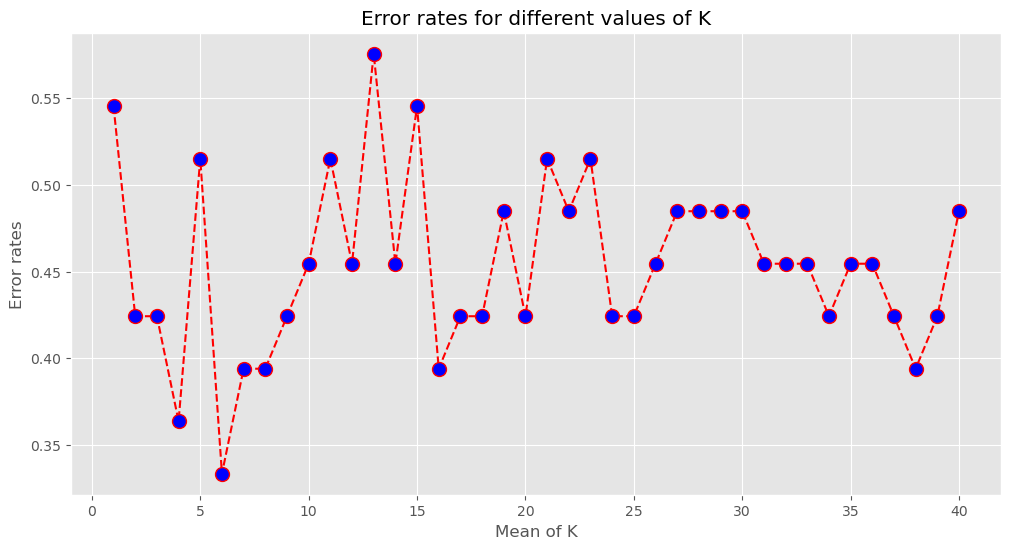

In [157]:
plt.figure(figsize = (12, 6))
plt.plot(range(1, 41), error_rate, color = 'red', linestyle = "dashed", marker = 'o', markerfacecolor = 'blue', markersize = 10)
plt.title(u'Error rates for different values of K')
plt.xlabel(u'Mean of K')
plt.ylabel(u'Error rates')
plt.show()